In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
dataset_path = "Waste_Dataset"

In [3]:
print("Dataset Path:", dataset_path)
print("Folder Exists:", os.path.exists(dataset_path))

Dataset Path: Waste_Dataset
Folder Exists: True


In [4]:
classes = os.listdir(dataset_path)

print("Waste Categories:")

for category in classes:
    print(category)

Waste Categories:
battery
glass
metal
organic_waste
paper_cardboard
plastic
textiles


In [5]:
for category in classes:

    folder = os.path.join(dataset_path, category)

    print(category, ":", len(os.listdir(folder)), "images")

battery : 8000 images
glass : 8000 images
metal : 8000 images
organic_waste : 8000 images
paper_cardboard : 8000 images
plastic : 8000 images
textiles : 8000 images


In [6]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [7]:
import tensorflow as tf

SC_train_dataset = tf.keras.utils.image_dataset_from_directory(
    "Waste_Dataset",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

SC_validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "Waste_Dataset",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

Found 56000 files belonging to 7 classes.
Using 44800 files for training.
Found 56000 files belonging to 7 classes.
Using 11200 files for validation.


In [8]:
SC_class_names = SC_train_dataset.class_names

print("Waste Categories:")
print(SC_class_names)

Waste Categories:
['battery', 'glass', 'metal', 'organic_waste', 'paper_cardboard', 'plastic', 'textiles']


In [11]:
def normalize_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

SC_train_dataset = SC_train_dataset.map(normalize_image)
SC_validation_dataset = SC_validation_dataset.map(normalize_image)


In [12]:
for SC_images, SC_labels in SC_train_dataset.take(1):
    print("Minimum Pixel Value:", tf.reduce_min(SC_images).numpy())
    print("Maximum Pixel Value:", tf.reduce_max(SC_images).numpy())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [14]:
# Data Augmentation for Training Dataset

SC_data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [15]:
# Convolutional Neural Network (CNN) Model Architecture

SC_model = tf.keras.Sequential([

    # First Convolution Block
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Block
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Third Convolution Block
    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(
        units=128,
        activation='relu'
    ),

    # Dropout Layer
    tf.keras.layers.Dropout(0.5),

    # Output Layer
    tf.keras.layers.Dense(
        units=7,
        activation='softmax'
    )

])

C:\Users\sampu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
SC_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
SC_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
SC_EPOCHS = 20

SC_history = SC_model.fit(
    SC_train_dataset,
    validation_data=SC_validation_dataset,
    epochs=SC_EPOCHS
)

Epoch 1/20


C:\Users\sampu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1400/1400 ━━━━━━━━━━━━━━━━━━━━ 795s 566ms/step - accuracy: 0.4304 - loss: 1.5348 - val_accuracy: 0.5485 - val_loss: 1.2413
Epoch 2/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 850s 607ms/step - accuracy: 0.5670 - loss: 1.2002 - val_accuracy: 0.6192 - val_loss: 1.0653
Epoch 3/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 1072s 766ms/step - accuracy: 0.6453 - loss: 0.9868 - val_accuracy: 0.6604 - val_loss: 0.9863
Epoch 4/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 889s 635ms/step - accuracy: 0.7209 - loss: 0.7854 - val_accuracy: 0.6926 - val_loss: 0.9346
Epoch 5/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 878s 627ms/step - accuracy: 0.7754 - loss: 0.6316 - val_accuracy: 0.7180 - val_loss: 0.8995
Epoch 6/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 676s 483ms/step - accuracy: 0.8196 - loss: 0.5117 - val_accuracy: 0.7244 - val_loss: 0.9262
Epoch 7/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 693s 495ms/step - accuracy: 0.8471 - loss: 0.4284 - val_accuracy: 0.7314 - val_loss: 0.9956
Epoch 8/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 755s 539ms/step - accuracy: 0.

In [19]:
SC_model.save("SC_Smart_Waste_Management_Model.keras")

In [20]:
# Evaluate the Trained CNN Model

SC_loss, SC_accuracy = SC_model.evaluate(SC_validation_dataset)

print("Validation Loss:", SC_loss)
print("Validation Accuracy:", SC_accuracy)

350/350 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.7526 - loss: 1.5547
Validation Loss: 1.554724097251892
Validation Accuracy: 0.7525892853736877


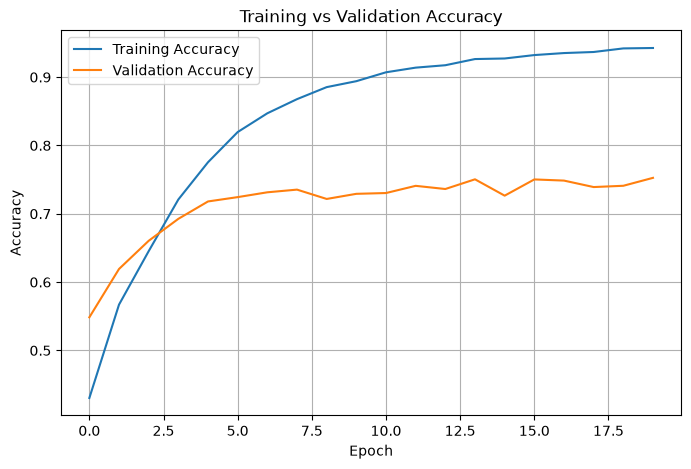

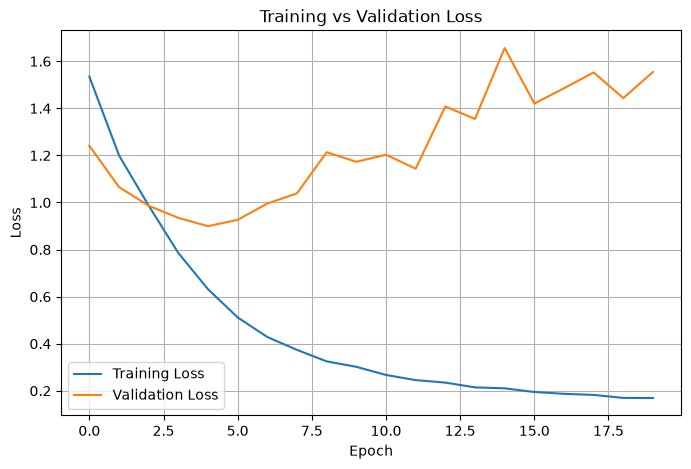

In [21]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(SC_history.history['accuracy'], label='Training Accuracy')
plt.plot(SC_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(SC_history.history['loss'], label='Training Loss')
plt.plot(SC_history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
SC_model.save("SC_Smart_Waste_Management_Model.keras")